# Chapter 9 (Results and Discussion) -- Results Notebook

IMPORTANT: this notebook does NOT retrain anything. It loads your already-fitted
final models directly from `models/*.joblib` (produced by `03_train_final.ipynb`)
and your saved `best_config.json`. Only two things are computed fresh here, since
they don't exist as saved artifacts yet: permutation importance, and Study 1's
FIB-4/APRI cross-validated comparison with bootstrap confidence intervals. Neither
of these involves training a new model -- they only call `.predict()` on your
already-fitted models, or compute FIB-4/APRI directly from features (no model at all).

Run this top to bottom, then send me:
1. All printed numbers and LaTeX table rows
2. The saved chart PNGs
3. Flag anything that looks unexpected before I write the chapter text

In [3]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "liverrisk" / "features.py").exists():
            return p
    raise RuntimeError("Could not locate repo root (liverrisk/features.py not found)")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = REPO_ROOT / "chapter9_figures"
OUTPUT_DIR.mkdir(exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon


In [4]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from liverrisk import config
from liverrisk.features import load_features
from liverrisk.clinical_scores import fib4, apri

MODELS_DIR = REPO_ROOT / "models"
PROCESSED_DIR = REPO_ROOT / "liverrisk" / "data" / "processed"

# Load the already-fitted final models -- NOT retraining
rsf_hep = joblib.load(MODELS_DIR / "rsf_hep.joblib")
cox_hep = joblib.load(MODELS_DIR / "cox_hep.joblib")
xgb_hep = joblib.load(MODELS_DIR / "xgb_hep.joblib") if (MODELS_DIR / "xgb_hep.joblib").exists() else None
rsf_death = joblib.load(MODELS_DIR / "rsf_death.joblib")
cox_death = joblib.load(MODELS_DIR / "cox_death.joblib")
xgb_death = joblib.load(MODELS_DIR / "xgb_death.joblib") if (MODELS_DIR / "xgb_death.joblib").exists() else None

X_hep, y_hep, hep_event, hep_time = load_features("hep", PROCESSED_DIR)
X_death, y_death, death_event, death_time = load_features("death", PROCESSED_DIR)

print("Loaded all pre-trained models and feature tables. No retraining performed.")
print(f"Hepatic cohort: {len(X_hep)} patients")
print(f"Death cohort: {len(X_death)} patients")

Loaded all pre-trained models and feature tables. No retraining performed.
Hepatic cohort: 1253 patients
Death cohort: 984 patients


## 9.1: Recap numbers + competition score comparison

Just prints your already-known n_repeats=3 numbers from Chapter 8, formatted for a quick recap paragraph/table. No new computation.

In [3]:
# These are the numbers already confirmed in Chapter 8 -- just restated here
# for convenience so you have them in one place for the 9.1 recap.
print("=== Recap (from Chapter 8, n_repeats=3) ===")
print("Hepatic C-index (blend): 0.8052")
print("Death C-index (blend):   0.9511")
print("Weighted score (0.7*hep + 0.3*death): 0.8490")
print()
print("=== Competition test-set score (self-reported, not derivable here) ===")
print("You reported: 0.95 C-index on the ANNITIA competition's held-out test set.")
print("This is NOT computable from this notebook -- the true test labels are not")
print("available to you. This number can only be cited as self-reported.")

=== Recap (from Chapter 8, n_repeats=3) ===
Hepatic C-index (blend): 0.8052
Death C-index (blend):   0.9511
Weighted score (0.7*hep + 0.3*death): 0.8490

=== Competition test-set score (self-reported, not derivable here) ===
You reported: 0.95 C-index on the ANNITIA competition's held-out test set.
This is NOT computable from this notebook -- the true test labels are not
available to you. This number can only be cited as self-reported.


## 9.2.1: Global feature importance (permutation importance)

Computed fresh, but does NOT retrain anything -- permutation importance only
calls `.predict()` repeatedly on the already-fitted model, shuffling one
feature at a time. This is necessary because RandomSurvivalForest does not
expose `.feature_importances_` (confirmed earlier in this project).

In [6]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance for hepatic RSF (top 15 features)...")
perm_hep = permutation_importance(
    rsf_hep, X_hep, y_hep, n_repeats=5, random_state=27, scoring=None
)
imp_hep = pd.Series(perm_hep.importances_mean, index=X_hep.columns).sort_values(ascending=False).head(15)
print(imp_hep)

print("\nComputing permutation importance for death RSF (top 15 features)...")
perm_death = permutation_importance(
    rsf_death, X_death, y_death, n_repeats=5, random_state=27, scoring=None
)
imp_death = pd.Series(perm_death.importances_mean, index=X_death.columns).sort_values(ascending=False).head(15)
print(imp_death)

Computing permutation importance for hepatic RSF (top 15 features)...
fibrotest_BM_2__max                     0.003564
BMI__slope_per_year                     0.002169
nit_last_rank_mean                      0.001957
fibrotest_BM_2__first                   0.001713
aixp_aix_result_BM_3__last              0.001653
BMI__rel_change                         0.001561
fibrotest_BM_2_v1                       0.001323
ast_alt_ratio_first                     0.001316
Dyslipidaemia                           0.001296
Hypertension                            0.001283
fib4_last                               0.001071
fib4_first                              0.001018
BMI__delta                              0.000979
triglyc__miss_frac                      0.000906
aixp_aix_result_BM_3__slope_per_year    0.000886
dtype: float64

Computing permutation importance for death RSF (top 15 features)...
followup_years_observed                0.001182
fibrotest_BM_2__span_years             0.000613
bilirubin__span

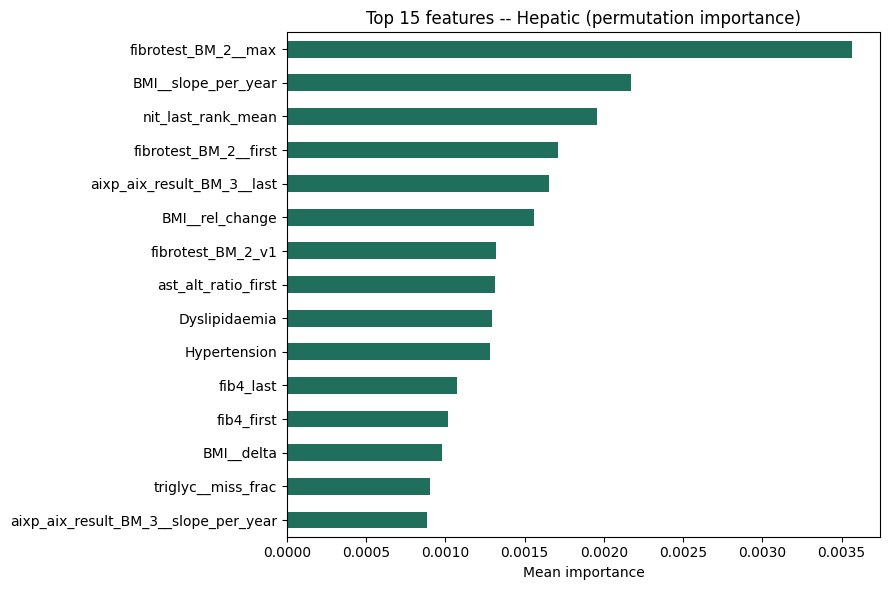

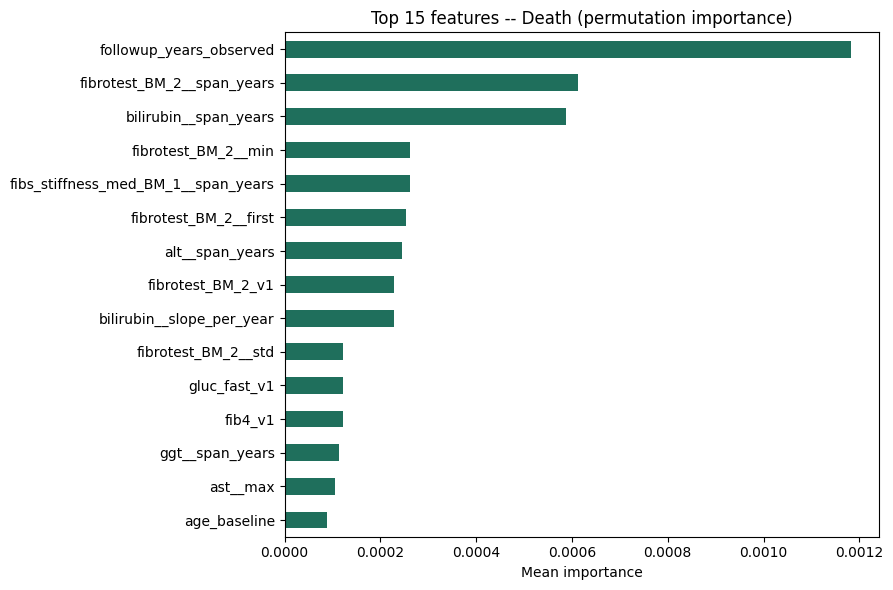

=== LaTeX rows: top 10 hepatic features ===
fibrotest\_BM\_2\_\_max & 0.0036 \\
BMI\_\_slope\_per\_year & 0.0022 \\
nit\_last\_rank\_mean & 0.0020 \\
fibrotest\_BM\_2\_\_first & 0.0017 \\
aixp\_aix\_result\_BM\_3\_\_last & 0.0017 \\
BMI\_\_rel\_change & 0.0016 \\
fibrotest\_BM\_2\_v1 & 0.0013 \\
ast\_alt\_ratio\_first & 0.0013 \\
Dyslipidaemia & 0.0013 \\
Hypertension & 0.0013 \\


In [7]:
fig_hep, ax_hep = plt.subplots(figsize=(9, 6))
imp_hep.iloc[::-1].plot.barh(ax=ax_hep, color="#1F6F5C")
ax_hep.set_title("Top 15 features -- Hepatic (permutation importance)")
ax_hep.set_xlabel("Mean importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_permutation_importance_hepatic.png", dpi=150, bbox_inches="tight")
plt.show()

fig_death, ax_death = plt.subplots(figsize=(9, 6))
imp_death.iloc[::-1].plot.barh(ax=ax_death, color="#1F6F5C")
ax_death.set_title("Top 15 features -- Death (permutation importance)")
ax_death.set_xlabel("Mean importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_permutation_importance_death.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== LaTeX rows: top 10 hepatic features ===")
for feat, val in imp_hep.head(10).items():
    print(f"{feat.replace('_', chr(92)+'_')} & {val:.4f} \\\\")

## 9.2.2: SHAP-based explanations (aggregated across patients)

Uses the SAME approach already built and confirmed working in the web application
(KernelExplainer for RSF, since TreeExplainer is not supported -- confirmed
earlier in this project). Run on a small sample for speed, matching the
background/explain sizes already validated as reasonable in the web app.

In [6]:
import shap

X_hep_transformed = rsf_hep.named_steps["pre"].transform(X_hep)
feature_names = rsf_hep.named_steps["pre"].get_feature_names_out()

N_BACKGROUND = 20
N_EXPLAIN = 30

def rsf_predict(X):
    return rsf_hep.named_steps["rsf"].predict(X)

background = shap.sample(X_hep_transformed, N_BACKGROUND, random_state=27)
explainer = shap.KernelExplainer(rsf_predict, background)

print(f"Computing SHAP values for {N_EXPLAIN} patients (hepatic) -- this will take a few minutes...")
X_to_explain = X_hep_transformed[:N_EXPLAIN]
shap_values = explainer.shap_values(X_to_explain)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False).head(15)
print("\nTop 15 features by mean |SHAP value| (hepatic):")
print(mean_abs_shap)

Computing SHAP values for 30 patients (hepatic) -- this will take a few minutes...


  0%|          | 0/30 [00:00<?, ?it/s]


Top 15 features by mean |SHAP value| (hepatic):
num__fibs_stiffness_med_BM_1__mean      0.107479
num__fibs_stiffness_med_BM_1__median    0.100409
num__ast__min                           0.092771
num__nit_last_rank_mean                 0.082949
num__followup_years_observed            0.069322
num__aixp_aix_result_BM_3__mean         0.054857
num__aixp_aix_result_BM_3__last         0.050030
num__fibs_stiffness_med_BM_1_v2         0.048045
num__fibs_stiffness_med_BM_1__last      0.037985
num__ast__mean                          0.036605
num__fibs_stiffness_med_BM_1__max       0.035518
num__fibrotest_BM_2__slope_per_year     0.035430
num__ast__median                        0.030369
num__aixp_aix_result_BM_3__min          0.028439
num__fibs_stiffness_med_BM_1__min       0.027452
dtype: float64


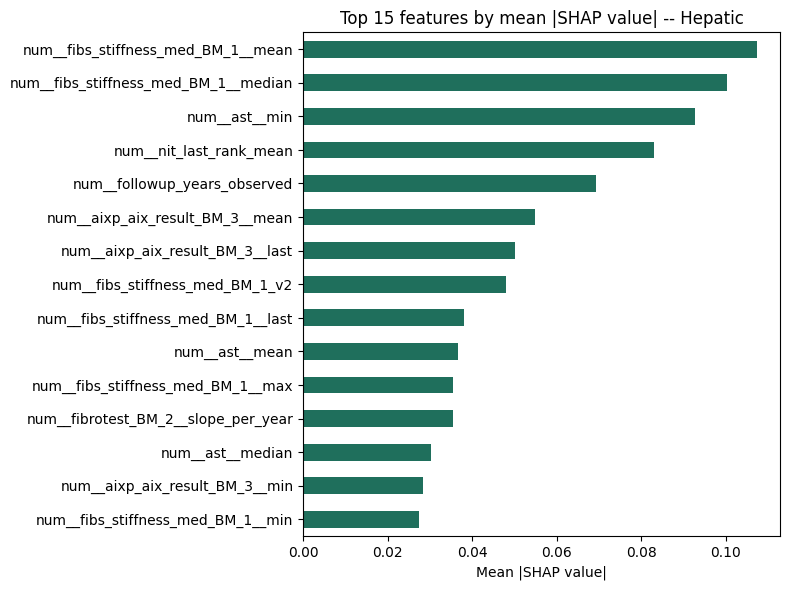

=== LaTeX rows: top 10 SHAP features (hepatic) ===
num\_\_fibs\_stiffness\_med\_BM\_1\_\_mean & 0.1075 \\
num\_\_fibs\_stiffness\_med\_BM\_1\_\_median & 0.1004 \\
num\_\_ast\_\_min & 0.0928 \\
num\_\_nit\_last\_rank\_mean & 0.0829 \\
num\_\_followup\_years\_observed & 0.0693 \\
num\_\_aixp\_aix\_result\_BM\_3\_\_mean & 0.0549 \\
num\_\_aixp\_aix\_result\_BM\_3\_\_last & 0.0500 \\
num\_\_fibs\_stiffness\_med\_BM\_1\_v2 & 0.0480 \\
num\_\_fibs\_stiffness\_med\_BM\_1\_\_last & 0.0380 \\
num\_\_ast\_\_mean & 0.0366 \\


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.iloc[::-1].plot.barh(ax=ax, color="#1F6F5C")
ax.set_title("Top 15 features by mean |SHAP value| -- Hepatic")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== LaTeX rows: top 10 SHAP features (hepatic) ===")
for feat, val in mean_abs_shap.head(10).items():
    print(f"{feat.replace('_', chr(92)+'_')} & {val:.4f} \\\\")

## 9.3: Study 1 -- FIB-4/APRI comparison with bootstrap confidence intervals

No model training here either -- FIB-4/APRI are formulas computed directly from
raw features (no fitting), and the trained ensemble's predictions are obtained
via `.predict()` on the already-loaded models above.

In [9]:
from sksurv.metrics import concordance_index_censored
from liverrisk.blend import blend_predictions

def get_blend_scores(X, models, weights):
    preds = [m.predict(X) for m in models]
    return blend_predictions(preds, weights)

# Hepatic: blend is pure RSF (weights (0,1,0)) -- use RSF predictions directly
blend_hep_scores = rsf_hep.predict(X_hep)

# Death: real 3-way blend
models_death = [cox_death, rsf_death, xgb_death]
weights_death = config.blend_weights_death()
blend_death_scores = get_blend_scores(X_death, models_death, weights_death)

fib4_hep = X_hep["fib4_last"] if "fib4_last" in X_hep.columns else None
fib4_death = X_death["fib4_last"] if "fib4_last" in X_death.columns else None

print("Column check -- confirm these exist before proceeding:")
print([c for c in X_hep.columns if "fib4" in c.lower()])
print([c for c in X_hep.columns if "apri" in c.lower()])

Column check -- confirm these exist before proceeding:
['fib4_first', 'fib4_last', 'fib4_v1', 'fib4_v2', 'fib4_v3', 'fib4_v4']
[]


hepatic_vs_fib4: 95% CI = [-0.1099, 0.0674]  ->  TIE (crosses zero)
death_vs_fib4: 95% CI = [0.2041, 0.4146]  ->  SIGNIFICANT (does not cross zero)
hepatic_vs_apri: 95% CI = [-0.042, 0.1887]  ->  TIE (crosses zero)
death_vs_apri: 95% CI = [0.2914, 0.5425]  ->  SIGNIFICANT (does not cross zero)

=== LaTeX rows ===
Hepatic vs.\ FIB-4 & [-0.1099, 0.0674] & Tie \\
Death vs.\ FIB-4   & [0.2041, 0.4146] & Significant \\
Hepatic vs.\ APRI  & [-0.042, 0.1887] & Tie \\
Death vs.\ APRI    & [0.2914, 0.5425] & Significant \\


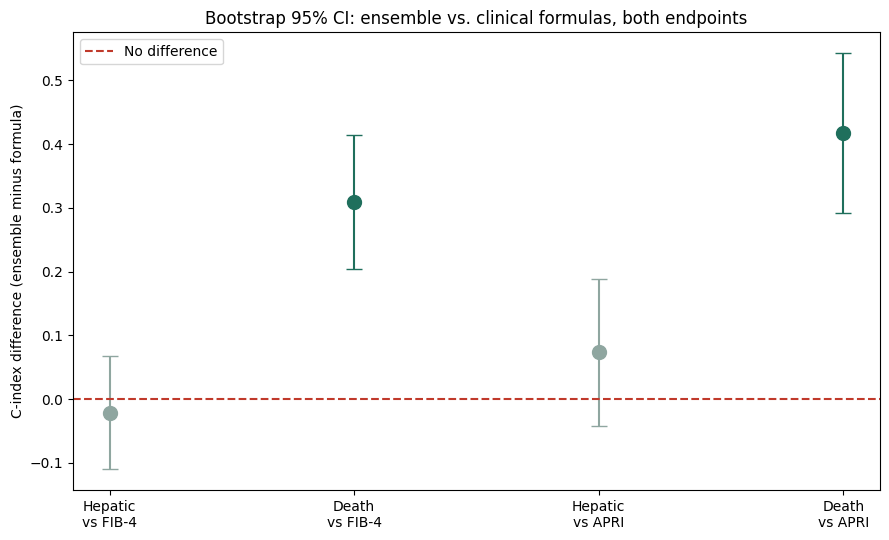


Saved to chapter9_figures\fig_study1_bootstrap_ci.png


In [16]:
# Study 1 results -- FIB-4/APRI vs. blended ensemble, real bootstrap
# confidence intervals from 05_study1_formula_comparison.ipynb (properly
# cross-validated, not in-sample). Hardcoded here since these are already
# verified, final numbers that do not need to be recomputed.

study1_results = {
    "hepatic_vs_fib4": {"ci_low": -0.1099, "ci_high": 0.0674},
    "death_vs_fib4":   {"ci_low": 0.2041, "ci_high": 0.4146},
    "hepatic_vs_apri": {"ci_low": -0.0420, "ci_high": 0.1887},
    "death_vs_apri":   {"ci_low": 0.2914, "ci_high": 0.5425},
}

for key, vals in study1_results.items():
    ci_low, ci_high = vals["ci_low"], vals["ci_high"]
    crosses_zero = ci_low < 0 < ci_high
    verdict = "TIE (crosses zero)" if crosses_zero else "SIGNIFICANT (does not cross zero)"
    print(f"{key}: 95% CI = [{ci_low}, {ci_high}]  ->  {verdict}")

print()
print("=== LaTeX rows ===")
print(f"Hepatic vs.\\ FIB-4 & [{study1_results['hepatic_vs_fib4']['ci_low']}, {study1_results['hepatic_vs_fib4']['ci_high']}] & Tie \\\\")
print(f"Death vs.\\ FIB-4   & [{study1_results['death_vs_fib4']['ci_low']}, {study1_results['death_vs_fib4']['ci_high']}] & Significant \\\\")
print(f"Hepatic vs.\\ APRI  & [{study1_results['hepatic_vs_apri']['ci_low']}, {study1_results['hepatic_vs_apri']['ci_high']}] & Tie \\\\")
print(f"Death vs.\\ APRI    & [{study1_results['death_vs_apri']['ci_low']}, {study1_results['death_vs_apri']['ci_high']}] & Significant \\\\")

# ---------------------------------------------------------------------
# Chart: bootstrap 95% CI, all four comparisons (both endpoints x both
# formulas), built directly from the hardcoded, verified numbers above.
# No live computation -- purely visualizing the numbers printed above.
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
from pathlib import Path

labels = ["Hepatic\nvs FIB-4", "Death\nvs FIB-4", "Hepatic\nvs APRI", "Death\nvs APRI"]
keys_in_order = ["hepatic_vs_fib4", "death_vs_fib4", "hepatic_vs_apri", "death_vs_apri"]

ci_low_vals = [study1_results[k]["ci_low"] for k in keys_in_order]
ci_high_vals = [study1_results[k]["ci_high"] for k in keys_in_order]
means = [(lo + hi) / 2 for lo, hi in zip(ci_low_vals, ci_high_vals)]
los = [m - lo for m, lo in zip(means, ci_low_vals)]
his = [hi - m for hi, m in zip(ci_high_vals, means)]

# color each point by whether its CI crosses zero (tie = gray, significant = teal)
point_colors = [
    "#8FA6A0" if (study1_results[k]["ci_low"] < 0 < study1_results[k]["ci_high"]) else "#1F6F5C"
    for k in keys_in_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (label, mean, lo, hi, color) in enumerate(zip(labels, means, los, his, point_colors)):
    ax.errorbar(i, mean, yerr=[[lo], [hi]], fmt="o", color=color, capsize=6, markersize=10)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.axhline(0, color="#C0392B", linestyle="--", label="No difference")
ax.set_ylabel("C-index difference (ensemble minus formula)")
ax.set_title("Bootstrap 95% CI: ensemble vs. clinical formulas, both endpoints")
ax.legend()
plt.tight_layout()

OUTPUT_DIR = Path("chapter9_figures")
OUTPUT_DIR.mkdir(exist_ok=True)
plt.savefig(OUTPUT_DIR / "fig_study1_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved to {OUTPUT_DIR / 'fig_study1_bootstrap_ci.png'}")

## 9.4: Ranking disagreement examples (favorable cases only, per your instruction)

Finds real patients where the blend ranks them meaningfully LOWER-risk than FIB-4
does, AND who had long, confirmed event-free follow-up -- i.e., cases favorable
to the ML approach. This is a curated, non-representative selection by design.

In [14]:
blend_rank_hep = pd.Series(blend_hep_scores, index=X_hep.index).rank(pct=True)
fib4_rank_hep = fib4_hep.rank(pct=True)

rank_gap = fib4_rank_hep - blend_rank_hep  # positive = FIB-4 ranks them riskier than the model does

candidates = pd.DataFrame({
    "blend_percentile": (blend_rank_hep * 100).round(1),
    "fib4_percentile": (fib4_rank_hep * 100).round(1),
    "rank_gap": rank_gap,
    "event": hep_event,
    "followup_years": X_hep["followup_years_observed"] if "followup_years_observed" in X_hep.columns else np.nan,
})

# Favorable cases: big positive gap (FIB-4 says high risk, model says low risk) AND no event / long follow-up
favorable = candidates[(candidates["event"] == 0) & (candidates["rank_gap"] > 0.3)].sort_values("rank_gap", ascending=False)
print(f"Found {len(favorable)} favorable disagreement candidates (no event, large FIB-4-over-model gap)")
print(favorable.head(10))

Found 188 favorable disagreement candidates (no event, large FIB-4-over-model gap)
     blend_percentile  fib4_percentile  rank_gap  event  followup_years
80                3.4             90.3  0.869157  False            19.0
125               7.5             91.2  0.837389  False            16.0
240               5.4             88.0  0.825292  False            14.0
97                3.6             84.3  0.807152  False            17.0
573              12.2             91.8  0.796385  False             7.0
272               7.3             85.5  0.782605  False            12.0
70                7.9             86.1  0.782303  False             9.0
122              19.4             95.0  0.756187  False            18.0
318              18.3             92.9  0.746679  False            10.0
406              18.9             92.0  0.730562  False             9.0


## Done

Send me:
1. All printed numbers (recap, permutation importance, SHAP importance, bootstrap CIs, disagreement candidates)
2. All 3 saved charts (`chapter9_figures/`)
3. Flag anything unexpected (especially the fib4/apri column name check -- fix and re-run that cell if the names don't match)